---
title: "Pandas 基础入门"
description: "本内容面向的读者是没有编程经验的纯编程小白，可以帮助你学习 Pandas 库基础"
date: 2026-08-31

categories:
  - Pandas
  - Code
  - Python
---

此处为提供的一个代码编辑区，可以帮助你简单的使用Pandas：

```{pyodide}
#| caption: "代码编辑区"
# 提供的简单Pandas代码编辑区
```

## 对象的创建

- 导入Pandas时,通常会给其一个别名`pd`,即`import pandas as pd`
- 作为标签库，Pandas对象在NumPy数组基础上给予其行**列标签**。可以说列表之于字典，就如NumPy之于Pandas。
- Pandas中，所有数组特性仍在，Pandas的数据以NumPy数组的方式存储。

In [74]:
import pandas as pd


### 一维对象的创建

#### 字典创建法

我们前面学习的NumPy中,可以使用`np.array()`将列表转换为NumPy数组.同样的,在Pandas中,可以通过`pd.Series()`函数,将字典转化为Series对象.

In [1]:
dict_v = {'a':0, 'b':0.25, 'c':0.5, 'd':0.75, 'e':1}
print(dict_v)

{'a': 0, 'b': 0.25, 'c': 0.5, 'd': 0.75, 'e': 1}


In [4]:
# 用字典创建对象
sr = pd.Series(dict_v)
print(sr)

a    0.00
b    0.25
c    0.50
d    0.75
e    1.00
dtype: float64


这种方法还要创建字典，有点太麻烦，个人推荐下面一种方法。

#### 数组创建法

最直接的创建方法是直接给`pd.Series()`函数参数，其需要两个参数。第一个是参数值`values`(列表，数组，张量均可)，第二个是键`index`(索引)

In [5]:
v = [0, 0.25, 0.5, 0.75, 1.]
k = ['a', 'b', 'c', 'd', 'e']

sr = pd.Series(v, index=k)
sr

a    0.00
b    0.25
c    0.50
d    0.75
e    1.00
dtype: float64

其中，参数index可以省略，省略后索引即从0开始的顺序数字。

In [6]:
sr_1 = pd.Series(v)
sr_1

0    0.00
1    0.25
2    0.50
3    0.75
4    1.00
dtype: float64

### 一维对象的属性

Series对象有两个属性: `values` 和  `index`

In [11]:
v = [53, 64, 72, 82]
sr = pd.Series(v)

print(sr.values)
print(sr.index)

k = ['一号', '二号', '三号', '四号']
sr_1 = pd.Series(v, k)
print(sr_1.index)

[53 64 72 82]
RangeIndex(start=0, stop=4, step=1)
Index(['一号', '二号', '三号', '四号'], dtype='object')


可见，虽然Pandas对象的第一个参数values可以传入列表、数组与张量，但传进去后默认的存储方式是NumPy数组。这一点更加提醒我们，Pandas是建立在NumPy基础上的库，没有NumPy数组库就没有Pandas数据处理库。

当想要Pandas退化为NumPy时，查看其values属性即可。

### 二维对象的创建

二维对象将面向矩阵，其不仅有行标签`index`， 还有列标签`columns`。

#### 字典创建法

用字典法创建二维对象时，必须基于多个Series对象，每一个Series就是一列数据，相当于对一列一列的数据作拼接。

- 创建Series对象时，字典的键是index，其延展方向是竖直方向；
- 创建DataFrame对象时，字典的键是columns，其延展方向是水平方向。

In [12]:
# 创建sr1：各个病人的年龄
v1 = [53, 64, 72, 82]
i = ['一号', '二号', '三号', '四号']
sr1 = pd.Series(v1, i)
sr1

一号    53
二号    64
三号    72
四号    82
dtype: int64

In [13]:
# 创建sr2：各个病人的性别
v2 = ['女', '男', '男', '女']
i = ['一号', '二号', '三号', '四号']
sr2 = pd.Series(v2, i)
sr2

一号    女
二号    男
三号    男
四号    女
dtype: object

In [14]:
# 创建df对象
df = pd.DataFrame({'年龄':sr1, '性别':sr2})
df

,年龄,性别
一号,53,女
二号,64,男
三号,72,男
四号,82,女


如果sr1和 sr2 的 index不完全一致，那么二维对象的index会取srl与sr2的index的**交集**，相应的，该对象就会产生一定数量的缺失值(NaN)。

#### 数组创建法

最直接的创建方法即直接给pd.DataFrame函数参数，其需要三个参数。第一个参数是值values（数组），第二个参数是行标签index，第三个参数是列标签columns。其中，index和columns参数可以省略，省略后即从0开始的顺序数字。


In [15]:
import numpy as np

v = np.array([[53, '女'], [64, '男'], [72, '男'], [82, '女']])
i = ['一号', '二号', '三号', '四号']
col = ['年龄', '性别']

df = pd.DataFrame(v, i, col)
df

,年龄,性别
一号,53,女
二号,64,男
三号,72,男
四号,82,女


细心的同学可能会发现端倪，v中NumPy数组居然又含数字又含字符串，上次课中明明讲过数组只能容纳一种变量类型。这里的原理是，数组默默把数字转为了字符串，于是v就是一个**字符串型数组**。

In [ ]:
v

array([['53', '女'],
       ['64', '男'],
       ['72', '男'],
       ['82', '女']], dtype='<U21')

可以看到，类别为 `'<U21'`

#### 二维对象的属性

DataFrame对象的属性有三个：values, index, columns

In [17]:
df.values

array([['53', '女'],
       ['64', '男'],
       ['72', '男'],
       ['82', '女']], dtype=object)

In [18]:
df.index

Index(['一号', '二号', '三号', '四号'], dtype='object')

In [19]:
df.columns

Index(['年龄', '性别'], dtype='object')

## 对象的索引

在学习Pandas的索引之前，需要知道：

1. **Pandas的索引分为显式索引与隐式索引**。显式索引是使用Pandas对象提供的索引，而隐式索引是使用数组本身自带的从0开始的索引。

2. 现假设某演示代码中的索引是整数，这个时候显式索引和隐式索引可能会出乱子。于是，Pandas作者发明了**索引器loc(显式)**与**iloc(隐式)**，手动告诉程序自己这句话是显式索引还是隐式索引。

3. 本章示例中，若代码块出现两栏，则**左侧为显式索引，右侧为隐式索引**，左右两列属于平行关系，任选其一均可。

### 一维对象的索引

#### 访问元素

In [26]:
v1 = [53, 64, 72, 82]
k = ['一号', '二号', '三号', '四号']
sr1 = pd.Series(v1, k)
sr1

一号    53
二号    64
三号    72
四号    82
dtype: int64

In [27]:
# 显式索引
print(sr1.loc['三号'])

print(sr1.loc[['三号', '一号']])

sr1.loc['三号'] = 100
print(sr1)

72
三号    72
一号    53
dtype: int64
一号     53
二号     64
三号    100
四号     82
dtype: int64


In [28]:
# 隐式索引
print(sr1.iloc[1])

print(sr1.iloc[[0, 1]])

sr1.iloc[1] = 100
print(sr1)


64
一号    53
二号    64
dtype: int64
一号     53
二号    100
三号    100
四号     82
dtype: int64


#### 访问切片

使用显式索引的时候，`'一号':'三号'` 可以涵盖最后一个`'三号'`但隐式与之前一样。

In [42]:
v1 = [53, 64, 72, 82]
k = ['一号', '二号', '三号', '四号']
sr1 = pd.Series(v1, k)
sr1

一号    53
二号    64
三号    72
四号    82
dtype: int64

In [43]:
# 显式
print(sr1.loc['一号':'三号'])

# 切片与之前一致，仅是视图
cut = sr1.loc['一号':'三号']
cut.loc['一号'] = 100
print(sr1)

# 对象赋值仅是绑定
cut = sr1
cut.loc['三号'] = 200
print(sr1)

一号    53
二号    64
三号    72
dtype: int64
一号    100
二号     64
三号     72
四号     82
dtype: int64
一号    100
二号     64
三号    200
四号     82
dtype: int64


In [41]:
# 隐式
print(sr1.iloc[0:2])

# 切片与之前一致，仅是视图
cut = sr1.iloc[0:2]
cut.iloc[0] = 100
print(sr1)

# 对象赋值仅是绑定
cut = sr1
cut.iloc[2] = 200
print(sr1)


一号    53
二号    64
dtype: int64
一号    100
二号     64
三号     72
四号     82
dtype: int64
一号    100
二号     64
三号    200
四号     82
dtype: int64


如果想创建新变量，与NumPy中，使用`.copy()`方法即可。

### 二维对象的索引

在二维对象中，索引器不能去掉，否则会报错，因此必须适应索引器的存在。

#### 访问元素

In [44]:
v1 = [53, 64, 72, 82]
v2 = ['女', '男', '男', '女']
i = ['一号', '二号', '三号', '四号']
sr1 = pd.Series(v1, i)
sr2 = pd.Series(v2, i)
df = pd.DataFrame({'年龄':sr1, '性别':sr2})
df

,年龄,性别
一号,53,女
二号,64,男
三号,72,男
四号,82,女


In [48]:
# 显式
print(df.loc['一号', '年龄'])

print(df.loc[['一号', '三号'], ['性别', '年龄']])

df.loc['三号', '年龄'] = 100
print(df)

53
   性别  年龄
一号  女  53
三号  男  72
     年龄 性别
一号   53  女
二号   64  男
三号  100  男
四号   82  女


隐式与之前一致，只是把`.loc`换成了`iloc`，且索引变成了从0开始的顺序数字。此处就不写了。

#### 访问切片

In [50]:
v1 = [53, 64, 72, 82]
v2 = ['女', '男', '男', '女']
i = ['一号', '二号', '三号', '四号']
sr1 = pd.Series(v1, i)
sr2 = pd.Series(v2, i)
df = pd.DataFrame({'年龄':sr1, '性别':sr2})
df

,年龄,性别
一号,53,女
二号,64,男
三号,72,男
四号,82,女


In [51]:
df.loc['一号':'三号', '年龄']

一号    53
二号    64
三号    72
Name: 年龄, dtype: int64

In [52]:
df.loc['三号', :]

年龄    72
性别     男
Name: 三号, dtype: object

In [53]:
df.loc[:, '年龄']

一号    53
二号    64
三号    72
四号    82
Name: 年龄, dtype: int64

在显示索引中提取矩阵的行或列还有一种简便写法，即:

1. 提取二维对象的行：`df.loc['3号]`（原理是省略后面的冒号，隐式也可以）
2. 提取二维对象的列：`df[年龄']`（原理是列标签本身就是二维对象的键）

## 对象的变形

### 对象的转置

有时候提供的大数据很畸形，行是特征，列是个体，这必须要先进行转置。我们最喜欢的数据是一行为一个样本，一列为一个特征

In [54]:
# 畸形 df
v=[[53, 64, 72, 82],['女', '男', '男', '女']]
i=['年龄', '性别']
c=['1号', '2号', '3号', '4号']
df= pd.DataFrame(v, i, c)
df

,1号,2号,3号,4号
年龄,53,64,72,82
性别,女,男,男,女


In [55]:
df = df.T
df

,年龄,性别
1号,53,女
2号,64,男
3号,72,男
4号,82,女


### 对象的翻转
与NumPy中的左右与上下翻转类似。

In [ ]:
# 左右翻转
df = df.iloc[:, ::-1]
df

,性别,年龄
1号,女,53
2号,男,64
3号,男,72
4号,女,82


In [57]:
# 上下翻转
df = df.iloc[::-1, :]
df

,性别,年龄
4号,女,82
3号,男,72
2号,男,64
1号,女,53


### 对象的重塑

考虑到对象是含有行列标签的，.reshape()已不再适用，因此对象的重塑没有那么灵活。但可以做到将sr并入df，也可以将df割出sr。

In [60]:
# 用数组法创建 sr

i=['1号', '2号', '3号', '4号']
v1=[10,20,30,40]
v2=['女', '男', '男', '女']
v3=[1,2,3,4]
sr1 = pd.Series(v1,index=i)
sr2 = pd.Series(v2,index=i)
sr3 = pd.Series(v3,index=i)
sr1, sr2, sr3

(1号    10
 2号    20
 3号    30
 4号    40
 dtype: int64,
 1号    女
 2号    男
 3号    男
 4号    女
 dtype: object,
 1号    1
 2号    2
 3号    3
 4号    4
 dtype: int64)

In [61]:
df = pd.DataFrame({'年龄':sr1, '性别':sr2})
df

,年龄,性别
1号,10,女
2号,20,男
3号,30,男
4号,40,女


In [62]:
# 把sr3 并入 df中
df['牌照'] = sr3
df

,年龄,性别,牌照
1号,10,女,1
2号,20,男,2
3号,30,男,3
4号,40,女,4


In [63]:
# 把df['年龄']分离为sr4
sr4 = df['年龄']
sr4

1号    10
2号    20
3号    30
4号    40
Name: 年龄, dtype: int64

### 对象的拼接

Pandas 中有一个`pd.comcat()`函数，与`np.concatenate()`函数语法相似。

#### 一维对象的合并

In [64]:
#创建sr1和sr2
v1 = [10, 20, 30, 40]
v2 = [40, 50, 60]
k1=['1号', '2号', '3号', '4号']
k2 =['4号', '5号', '6号']
sr1 = pd.Series(v1, k1)
sr2 = pd.Series(v2, k2)
sr1, sr2

(1号    10
 2号    20
 3号    30
 4号    40
 dtype: int64,
 4号    40
 5号    50
 6号    60
 dtype: int64)

In [65]:
pd.concat([sr1, sr2])

1号    10
2号    20
3号    30
4号    40
4号    40
5号    50
6号    60
dtype: int64

值得注意的是，输出的键中出现了两个“4号”，这是因为Pandas对象的属性，放弃了集合与字典索引中 **“不可重复”** 的特性，实际中，这可以拓展大数据分析与处理的应用场景。那么，如何保证索引是不重复的呢？对对象的属性`.index`或`.columns`使用`.is_unique`即可检查，返回`True`表示行或列不重复，`False`表示有重复。

In [66]:
print(pd.concat([sr1, sr2]).index.is_unique)

False


#### 一维对象与二维对象的合并

一维对象与二维对象的合并，即可理解为：给二维对象加上一列或者一行。因此，不必使用`pd.concat()`函数，只需要借助`小节“二维对象的索引”`语法。

In [75]:
v1 = [20, 30 ,40]
v2 = ['man', 'woman', 'man']
k = ['num_1', 'num_2', 'num_3']
sr1 = pd.Series(v1, k)
sr2 = pd.Series(v2, k)
df = pd.DataFrame({'years':sr1, 'sex':sr2})
df

,years,sex
num_1,20,man
num_2,30,woman
num_3,40,man


In [76]:
# add one columns

df['money'] = [10000, 20000, 30000]
df

,years,sex,money
num_1,20,man,10000
num_2,30,woman,20000
num_3,40,man,30000


In [77]:
# add one rows
df.loc['num_4'] = [50, 'woman', 1000000]
df

,years,sex,money
num_1,20,man,10000
num_2,30,woman,20000
num_3,40,man,30000
num_4,50,woman,1000000


#### 二维对象合并

依旧适用`pd.concat()`函数,只是多了`axis`参数选择.

In [78]:
# 创建 df1, df2, df3
v1 = [[10, 'w'], [20, 'm'], [30, 'm'], [40, 'm']]
v2 = [[1, 'yes'], [2, 'yes'], [3, 'yes'], [4, 'no']]
v3 = [[50, 'm', 5, 'yes'], [60, 'w', 6, 'yes']]
i1 = ['n1', 'n2', 'n3', 'n4']
i2 = ['n1', 'n2', 'n3', 'n4']
i3 = ['n5', 'n6']
c1 = ['years', 'sex']
c2 = ['cards', 'ikun']
c3 = ['years', 'sex', 'cards', 'ikun']

df1 = pd.DataFrame(v1, i1, c1)
df2 = pd.DataFrame(v2, i2, c2)
df3 = pd.DataFrame(v3, i3, c3)

df1, df2, df3

(    years sex
 n1     10   w
 n2     20   m
 n3     30   m
 n4     40   m,
     cards ikun
 n1      1  yes
 n2      2  yes
 n3      3  yes
 n4      4   no,
     years sex  cards ikun
 n5     50   m      5  yes
 n6     60   w      6  yes)

In [79]:
# 我们可以先合并df1与df2，最后在合并到df3 .

df = pd.concat([df1, df2], axis = 1)

df = pd.concat([df, df3], axis = 0)

df

,years,sex,cards,ikun
n1,10,w,1,yes
n2,20,m,2,yes
n3,30,m,3,yes
n4,40,m,4,no
n5,50,m,5,yes
n6,60,w,6,yes


## 对象的运算

### 对象与系数之间的运算


In [80]:
sr = pd.Series([53, 64, 72], ['n1', 'n2', 'n3'])
sr

n1    53
n2    64
n3    72
dtype: int64

In [81]:
v = [[53, 'woman'], [64, 'man'], [72, 'man']]
df = pd.DataFrame(v, ['n1', 'n2', 'n3'], ['years', 'sex'])
df

,years,sex
n1,53,woman
n2,64,man
n3,72,man


In [82]:
# 针对一维

print(sr+10)
print(sr*10)
print(sr**10)

n1    63
n2    74
n3    82
dtype: int64
n1    530
n2    640
n3    720
dtype: int64
n1     174887470365513049
n2    1152921504606846976
n3    3743906242624487424
dtype: int64


In [84]:
# 针对二维
print(df['years']+10)
print(df['years']*10)
print(df['years']**10)

n1    63
n2    74
n3    82
Name: years, dtype: int64
n1    530
n2    640
n3    720
Name: years, dtype: int64
n1     174887470365513049
n2    1152921504606846976
n3    3743906242624487424
Name: years, dtype: int64


`df.values`是一个NumPy数组，其整体只能以`object`类型的混合形式存在，因此之前需要对单独的数字列进行`.astype(int)`的操作。

`df['年龄']`是Pandas对象的数字列，Pandas为数据处理而生，尽管整体表现为`object`，但每一列**数据单独存储**，因此数字列和字符列**完美共存**。

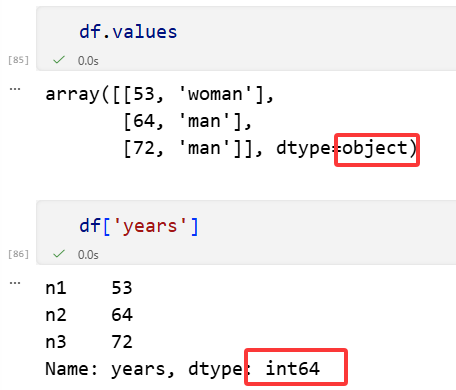

### 对象与对象之间的运算

对象做运算，必须保证其均是数字型对象，两个对象之间的维度可以不同。

#### 一维对象之间的运算

In [94]:
sr1 = pd.Series([10, 20, 30, 40], ['n1', 'n2', 'n3', 'n4'])
sr2 = pd.Series([1, 2, 3], ['n1', 'n2', 'n3'])

print(sr1+sr2)
print('*'*20)
print(sr1-sr2)
print('*'*20)
print(sr1*sr2)


n1    11.0
n2    22.0
n3    33.0
n4     NaN
dtype: float64
********************
n1     9.0
n2    18.0
n3    27.0
n4     NaN
dtype: float64
********************
n1    10.0
n2    40.0
n3    90.0
n4     NaN
dtype: float64


In [95]:
print(sr1/sr2)
print('*'*20)
print(sr1**sr2)
print('*'*20)

n1    10.0
n2    10.0
n3    10.0
n4     NaN
dtype: float64
********************
n1       10.0
n2      400.0
n3    27000.0
n4        NaN
dtype: float64
********************


#### 二维对象之间的运算

In [96]:
v1 = [[10, 'woman'], [20, 'man'], [30, 'man'], [40, 'woman']]
v2 = [1, 2, 3, 6]
i1 = ['n1', 'n2', 'n3', 'n4']
c1 = ['years', 'sex']
i2 = ['n1', 'n2', 'n3', 'n6']
c2 = ['cards']

df1 = pd.DataFrame(v1, i1, c1)
df2 = pd.DataFrame(v2, i2, c2)
df1, df2

(    years    sex
 n1     10  woman
 n2     20    man
 n3     30    man
 n4     40  woman,
     cards
 n1      1
 n2      2
 n3      3
 n6      6)

In [98]:
df1['add'] = df1['years'] + df2['cards']
df1

# 其余计算方法一致。

,years,sex,add
n1,10,woman,11.0
n2,20,man,22.0
n3,30,man,33.0
n4,40,woman,NaN


本章的最后，补充两点内容，读者可自行尝试。

- 使用`np.abs()`、`np.cos()`、`np.exp()`、`np.log()`等数学函数时，会保留索引；
- Pandas中仍然存在布尔型对象，用法与NumPy无异，会保留索引。

In [99]:
df1['cos'] = np.cos(df1['add'])
df1

,years,sex,add,cos
n1,10,woman,11.0,0.004426
n2,20,man,22.0,-0.999961
n3,30,man,33.0,-0.013277
n4,40,woman,NaN,NaN


## 对象的缺失值

### 发现缺失值

发现缺失值可以使用`.isnull()`方法。

In [101]:
v = [53, None, 72, 82]
k = ['n1', 'n2', 'n3', 'n4']
sr = pd.Series(v, k)
print(sr.isnull())

print(np.sum(sr.isnull()))

n1    False
n2     True
n3    False
n4    False
dtype: bool
1


In [113]:
v = [[None, 1], [64, None], [72, 3], [82, 4]]
i = ['1号', '2号', '3号', '4号']
c = ['年龄', '牌照']
df = pd.DataFrame(v, i, c)
print(df.isnull())
print(df.isnull().sum())
print(df.isnull().sum().sum())


       年龄     牌照
1号   True  False
2号  False   True
3号  False  False
4号  False  False
年龄    1
牌照    1
dtype: int64
2


除了`.isnull()`以外，还有一个与之相反的`.notnull()`方法，但不如在开头加一个非号`~`即可。如`~df.isnull()`

### 剔除缺失值

剔除缺失值使用`.dropna()`方法，一维对象很好剔除；二维对象比较复杂，要么单独剔除df中含有缺失值的行，要么剔除df中含有缺失值的列。

In [116]:
v = [53, None, 72, 82]
k = ['n1', 'n2', 'n3', 'n4']
sr = pd.Series(v, k)
sr.dropna()

n1    53.0
n3    72.0
n4    82.0
dtype: float64

In [ ]:
#创建df
v=[[None, None], [64, None], [72, 3],[82, 4]]
i=['n1', 'n2', 'n3', 'n4']
c=['years', 'cards']
df = pd.DataFrame(v, i, c)
print(df.dropna(axis=0))
print(df.dropna(axis='columns'))  # == axis=1

    years  cards
n3   72.0    3.0
n4   82.0    4.0
Empty DataFrame
Columns: []
Index: [n1, n2, n3, n4]


有些同学认为，只要某行含有一个NaN就剔除该个体太过残忍，我们可以设定一个参数，只有当该行全部是NaN，才剔除该列特征。

In [ ]:
df.dropna(how = 'all')

,years,cards
n2,64.0,NaN
n3,72.0,3.0
n4,82.0,4.0


In [125]:
df.dropna(how = 'all', axis=1)

,years,cards
n1,NaN,NaN
n2,64.0,NaN
n3,72.0,3.0
n4,82.0,4.0


### 填充缺失值

使用`.fillna()`方法，实际的数据填充没有统一的方法，非常灵活。

In [ ]:
v = [53, None, 72, 82]
k = ['n1', 'n2', 'n3', 'n4']
sr = pd.Series(v, k)
sr.fillna(0)

n1    53.0
n2     0.0
n3    72.0
n4    82.0
dtype: float64

In [127]:
sr.fillna(np.mean(sr))

n1    53.0
n2    69.0
n3    72.0
n4    82.0
dtype: float64

In [129]:
# 用前值填充
print(sr.ffill())
# 用后值填充
print(sr.bfill())

n1    53.0
n2    53.0
n3    72.0
n4    82.0
dtype: float64
n1    53.0
n2    72.0
n3    72.0
n4    82.0
dtype: float64


#### 二维对象进行填充

In [130]:
#创建df
v=[[None, None], [64, None], [72, 3],[82, 4]]
i=['n1', 'n2', 'n3', 'n4']
c=['years', 'cards']
df = pd.DataFrame(v, i, c)
df.fillna(0)

,years,cards
n1,0.0,0.0
n2,64.0,0.0
n3,72.0,3.0
n4,82.0,4.0


In [135]:
df.fillna(np.mean(df, axis=0))

,years,cards
n1,72.666667,3.5
n2,64.000000,3.5
n3,72.000000,3.0
n4,82.000000,4.0


In [ ]:
df.ffill() # 由于前面没有数据，故还是NaN

,years,cards
n1,NaN,NaN
n2,64.0,NaN
n3,72.0,3.0
n4,82.0,4.0


In [137]:
df.bfill()

,years,cards
n1,64.0,3.0
n2,64.0,3.0
n3,72.0,3.0
n4,82.0,4.0


## 导入Excel文件

### 创建excel文件

我们可以先建立如图的一个表格，记得转换为csv文件。放到与代码相同文件夹即可。

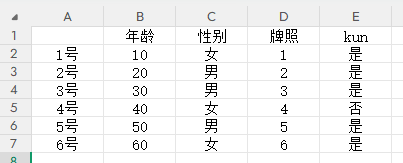

### 导入Excel信息

In [ ]:
df = pd.read_csv('data.csv', index_col=0,  encoding='gbk')
df
# index_col=0的作用是把 CSV 文件的第 0 列（第一列）设置为 DataFrame 的行索引（index），而不是普通的数据列。

,年龄,性别,牌照,kun
1号,10,女,1,是
2号,20,男,2,是
3号,30,男,3,是
4号,40,女,4,否
5号,50,男,5,是
6号,60,女,6,是


In [141]:
# 提取纯数组
arr = df.values
arr

array([[10, '女', 1, '是'],
       [20, '男', 2, '是'],
       [30, '男', 3, '是'],
       [40, '女', 4, '否'],
       [50, '男', 5, '是'],
       [60, '女', 6, '是']], dtype=object)

## 数据分析

### 导入信息

我们把如图表格导入：

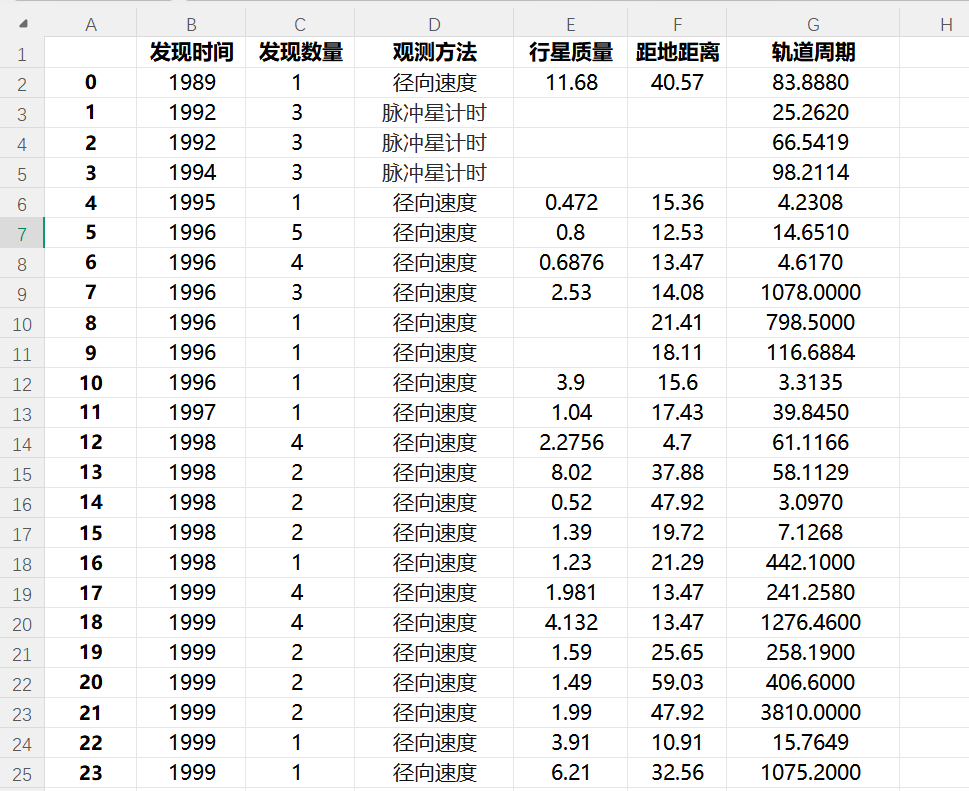

In [144]:
df = pd.read_csv('行星数据.csv', index_col=0, encoding='gbk')
df

,发现时间,发现数量,观测方法,行星质量,距地距离,轨道周期
0,1989,1,径向速度,11.680,40.57,83.8880
1,1992,3,脉冲星计时,NaN,NaN,25.2620
2,1992,3,脉冲星计时,NaN,NaN,66.5419
3,1994,3,脉冲星计时,NaN,NaN,98.2114
4,1995,1,径向速度,0.472,15.36,4.2308
...,...,...,...,...,...,...
1030,2014,1,凌日,NaN,NaN,2.4650
1031,2014,1,凌日,NaN,NaN,68.9584
1032,2014,1,凌日,NaN,1056.00,1.7209
1033,2014,1,凌日,NaN,NaN,66.2620


### 聚合方法

可在输出df时，对其使用`df.head()`，使其仅输出前5行。


In [145]:
df.head()

,发现时间,发现数量,观测方法,行星质量,距地距离,轨道周期
0,1989,1,径向速度,11.680,40.57,83.8880
1,1992,3,脉冲星计时,NaN,NaN,25.2620
2,1992,3,脉冲星计时,NaN,NaN,66.5419
3,1994,3,脉冲星计时,NaN,NaN,98.2114
4,1995,1,径向速度,0.472,15.36,4.2308


NumPy中所有的聚合函数对Pandas对象均适用。此外，Pandas将这些函数变为对象的方法，这样，不导入NumPy也可使用。

In [148]:
df.max()

发现时间        2014
发现数量           7
观测方法      轨道亮度调制
行星质量        25.0
距地距离      8500.0
轨道周期    730000.0
dtype: object

In [149]:
df.min()

发现时间      1989
发现数量         1
观测方法        凌日
行星质量    0.0036
距地距离      1.35
轨道周期    0.0907
dtype: object

In [151]:
df.mean(numeric_only=True)

发现时间    2009.070531
发现数量       1.785507
行星质量       2.638161
距地距离     264.069282
轨道周期    2002.917596
dtype: float64

In [153]:
df.std(numeric_only=True)

发现时间        3.972567
发现数量        1.240976
行星质量        3.818617
距地距离      733.116493
轨道周期    26014.728304
dtype: float64

In [154]:
df.sum()

发现时间                                              2079388
发现数量                                                 1848
观测方法    径向速度脉冲星计时脉冲星计时脉冲星计时径向速度径向速度径向速度径向速度径向速度径向速度径向速...
行星质量                                           1353.37638
距地距离                                            213367.98
轨道周期                                         1986894.2555
dtype: object

这些方法都忽略了缺失值，数据NumPy中聚合函数的安全版本。

### 描述方法

在数据分析中，用以上方法挨个查看未免太过麻烦，可以使用`.describe()`方法直接查看所有聚合函数的信息。

In [155]:
df.describe()

,发现时间,发现数量,行星质量,距地距离,轨道周期
count,1035.000000,1035.000000,513.000000,808.000000,992.000000
mean,2009.070531,1.785507,2.638161,264.069282,2002.917596
std,3.972567,1.240976,3.818617,733.116493,26014.728304
min,1989.000000,1.000000,0.003600,1.350000,0.090700
25%,2007.000000,1.000000,0.229000,32.560000,5.442575
50%,2010.000000,1.000000,1.260000,55.250000,39.979500
75%,2012.000000,2.000000,3.040000,178.500000,526.005000
max,2014.000000,7.000000,25.000000,8500.000000,730000.000000


第1行count是计数项，统计每个特征的有效数量（即排除缺失值），从count可以看出，行星质量的缺失值比较多，需要考虑一定的办法填充或舍弃。

第2行至第3行的mean与std统计每列特征的均值与标准差。

第4行至第8行的min、25%、50%、75%、max的意思是五个分位点，即把数组从小到大排序后，0%、25%、50%、75%、100%五个位置上的数值的取值。显然，50%分位点即中位数。

### 数据透视

#### 两个特征内的数据透视

数据透视，对数据分析来讲十分重要。

现以泰坦尼克号的生还数据为例，以“是否生还”特征为考察的核心（或者说是神经网络的输出），研究其它特征（输入）与之的关系，如示例所示。



In [157]:
df = pd.read_csv('泰坦尼克.csv', index_col=0, encoding='gbk')
df.head()


,性别,年龄,船舱等级,费用,是否生还
0,男,22.0,三等,7.2500,0
1,女,38.0,一等,71.2833,1
2,女,26.0,三等,7.9250,1
3,女,35.0,一等,53.1000,1
4,男,35.0,三等,8.0500,0


In [158]:
# 数据透视，一个特征：性别
df.pivot_table('是否生还', index='性别')

,是否生还
性别,
女,0.742038
男,0.188908


In [159]:
# 两个特征： 性别，船舱等级
df.pivot_table('是否生还', index='性别', columns='船舱等级')

船舱等级,一等,三等,二等
性别,,,
女,0.968085,0.500000,0.921053
男,0.368852,0.135447,0.157407


在上述示例中，数据透视表中的数值默认是输出特征“是否生还”的均值（mean），行标签和列标签变成了其它的输入特征。可以看出，女性整体的生还概率是74%，男性整体的生还概率为18%。

而另一个则区分的更细致，按照船舱等级的下降，生还率逐步下降。值得注意的是，pivot_table()方法有一个很重要的参数：`aggfunc`，其默认值是'mean'，除此以外，所有的聚合函数'max'、'min'、'sum'、'count’均可使用。

显然，对于这里的“是否生还”来说，'mean’就是最好的选择，其刚好为概率。

#### 多个特征的数据透视

前面的示例只涉及到两个特征，有时需要考察更多特征与输出特征的关系。

这里，将年龄和费用都加进去。但是，这两个特征的数值很分散，之前的性别和船舱等级都可以按照类别分，现在已经不能再按类别分了。因此，需要涉及到数据透视表配套的两个重要函数：`pd.cut()`与`pd.qcut()`。

In [161]:
# 重置年龄列
age = pd.cut(df['年龄'], [0, 25, 120]) # 以25岁为分水岭
age

0        (0.0, 25.0]
1      (25.0, 120.0]
2      (25.0, 120.0]
3      (25.0, 120.0]
4      (25.0, 120.0]
           ...      
886    (25.0, 120.0]
887      (0.0, 25.0]
888              NaN
889    (25.0, 120.0]
890    (25.0, 120.0]
Name: 年龄, Length: 891, dtype: category
Categories (2, interval[int64, right]): [(0, 25] < (25, 120]]

In [166]:
# 三个特征，性别，船舱等级，年龄
df.pivot_table('是否生还', index=['性别', age], columns='船舱等级', observed=True)

船舱等级                一等        三等        二等
性别 年龄                                     
女  (0, 25]    0.928571  0.507692  0.965517
   (25, 120]  0.982456  0.378378  0.888889
男  (0, 25]    0.500000  0.155039  0.277778
   (25, 120]  0.379310  0.145161  0.079365

In [163]:
# 重置费用列
fare = pd.qcut(df['费用'], 2) # 将费用自动分为两部分
fare

0       (-0.001, 14.454]
1      (14.454, 512.329]
2       (-0.001, 14.454]
3      (14.454, 512.329]
4       (-0.001, 14.454]
             ...        
886     (-0.001, 14.454]
887    (14.454, 512.329]
888    (14.454, 512.329]
889    (14.454, 512.329]
890     (-0.001, 14.454]
Name: 费用, Length: 891, dtype: category
Categories (2, interval[float64, right]): [(-0.001, 14.454] < (14.454, 512.329]]

In [165]:
# 四个特征：性别，船舱等级，年龄，费用
df.pivot_table('是否生还', index=['性别', age], columns=['船舱等级', fare], observed=True)

船舱等级                       一等                                 三等  \
费用           (-0.001, 14.454] (14.454, 512.329] (-0.001, 14.454]   
性别 年龄                                                              
女  (0, 25]                NaN          0.928571         0.589744   
   (25, 120]              NaN          0.982456         0.444444   
男  (0, 25]                NaN          0.500000         0.147368   
   (25, 120]              0.0          0.397590         0.134615   

船舱等级                                         二等                    
费用           (14.454, 512.329] (-0.001, 14.454] (14.454, 512.329]  
性别 年龄                                                              
女  (0, 25]            0.384615         0.857143          1.000000  
   (25, 120]          0.315789         0.904762          0.875000  
男  (0, 25]            0.176471         0.055556          0.500000  
   (25, 120]          0.200000         0.108108          0.038462

当然，这里只演示了4个特征，你可以继续在`pivot_table()`的`index`或`columns`的列表参数里添加其他特征，但也不要添加太多，会很混乱。